# Polars Proc Compare - Disk-Based Comparison Demo

This notebook demonstrates the disk-based comparison features for handling large datasets efficiently with minimal memory usage.

In [1]:
import polars as pl
import numpy as np
from pathlib import Path
from polars_proc_compare import DataCompare
from polars_proc_compare.data_generator import create_delta_dataset
import psutil
import tempfile

# Create directories for data and results
data_dir = Path("data")
results_dir = Path("results")
data_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

## Generate Large Test Datasets

Let's create two large datasets that would be memory-intensive to compare using the traditional in-memory approach.

In [2]:
import polars as pl
import numpy as np
from pathlib import Path
import gc
from datetime import datetime
from polars_proc_compare import DataCompare
from polars_proc_compare.data_generator import create_delta_dataset

# Create directories for data and results
data_dir = Path("data")
results_dir = Path("results")
data_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

def create_large_dataset(n_rows: int, n_cols: int, seed: int = 42) -> pl.DataFrame:
    """Create a large dataset with various data types."""
    np.random.seed(seed)
    
    # Create timestamps using Python's datetime
    start_ts = datetime(2024, 1, 1).timestamp()
    end_ts = datetime(2024, 12, 31).timestamp()
    timestamps = np.linspace(start_ts, end_ts, n_rows)
    
    # Create base data with explicit types
    data = {
        "id": pl.Series("id", range(n_rows), dtype=pl.Int64),  # Use Int64 instead of Int32
        "timestamp": pl.Series(
            "timestamp",
            timestamps,
            dtype=pl.Int64
        ).cast(pl.Datetime("ms"))
    }
    
    # Add numeric columns with non-optimal types
    for i in range(n_cols):
        if i % 3 == 0:  # Integer columns
            data[f"int_col_{i}"] = pl.Series(
                name=f"int_col_{i}",
                values=np.random.randint(-10000, 10000, n_rows),
                dtype=pl.Int64  # Use Int64 instead of Int32
            )
        elif i % 3 == 1:  # Float columns
            data[f"float_col_{i}"] = pl.Series(
                name=f"float_col_{i}",
                values=np.random.normal(0, 100, n_rows),
                dtype=pl.Float64  # Use Float64 instead of Float32
            )
        else:  # String columns (instead of categorical)
            categories = [f"cat_{j}" for j in range(10)]
            values = np.random.choice(categories, n_rows)
            data[f"cat_col_{i}"] = pl.Series(
                name=f"cat_col_{i}",
                values=values,
                dtype=pl.Utf8  # Use Utf8 instead of Categorical
            )
        
        # Free up memory after each column
        if i % 5 == 0:
            _ = gc.collect()
    
    df = pl.DataFrame(data)
    print(f"DataFrame schema: {df.schema}")
    return df

try:
    # Start with a very small dataset for testing
    print("Creating base dataset...")
    base_df = create_large_dataset(n_rows=10_000, n_cols=5)
    print(f"Base dataset shape: {base_df.shape}")
    print(f"Base dataset schema:\n{base_df.schema}")
    
    # Save to parquet
    base_path = data_dir / "base_large.parquet"
    base_df.write_parquet(base_path)
    print(f"Base dataset saved to {base_path}")
    
    print("\nCreating comparison dataset with modifications...")
    compare_df, modifications = create_delta_dataset(
        base_df,
        delta_percentage=1.0,  # 1% differences
        seed=42,
        exclude_columns=["id", "timestamp"]
    )
    print(f"Comparison dataset shape: {compare_df.shape}")
    print(f"Comparison dataset schema:\n{compare_df.schema}")
    
    # Save comparison dataset
    compare_path = data_dir / "compare_large.parquet"
    compare_df.write_parquet(compare_path)
    print(f"Comparison dataset saved to {compare_path}")
    
    # Clear dataframes to free memory
    del base_df, compare_df
    _ = gc.collect()
    
    # Print dataset info
    base_size = base_path.stat().st_size / (1024 * 1024)  # Size in MB
    compare_size = compare_path.stat().st_size / (1024 * 1024)  # Size in MB
    print(f"\nDataset sizes:")
    print(f"Base: {base_size:.2f} MB")
    print(f"Compare: {compare_size:.2f} MB")
    
except Exception as e:
    print(f"Error: {str(e)}")
    import traceback
    traceback.print_exc()
    # Clean up memory
    if 'base_df' in locals(): del base_df
    if 'compare_df' in locals(): del compare_df
    _ = gc.collect()

Creating base dataset...
DataFrame schema: OrderedDict({'id': Int64, 'timestamp': Datetime(time_unit='ms', time_zone=None), 'int_col_0': Int64, 'float_col_1': Float64, 'cat_col_2': Utf8, 'int_col_3': Int64, 'float_col_4': Float64})
Base dataset shape: (10000, 7)
Base dataset schema:
OrderedDict({'id': Int64, 'timestamp': Datetime(time_unit='ms', time_zone=None), 'int_col_0': Int64, 'float_col_1': Float64, 'cat_col_2': Utf8, 'int_col_3': Int64, 'float_col_4': Float64})
Base dataset saved to data/base_large.parquet

Creating comparison dataset with modifications...
Comparison dataset shape: (10000, 7)
Comparison dataset schema:
OrderedDict({'id': Int64, 'timestamp': Datetime(time_unit='ms', time_zone=None), 'int_col_0': Int64, 'float_col_1': Float64, 'cat_col_2': Utf8, 'int_col_3': Int64, 'float_col_4': Float64})
Comparison dataset saved to data/compare_large.parquet

Dataset sizes:
Base: 0.25 MB
Compare: 0.25 MB


## Compare Using Traditional In-Memory Mode

First, let's try to compare these datasets using the traditional in-memory approach to see why we need disk-based comparison.

In [3]:
def get_memory_usage():
    """Get current memory usage in GB."""
    process = psutil.Process()
    return process.memory_info().rss / (1024 * 1024 * 1024)

try:
    print(f"Initial memory usage: {get_memory_usage():.2f} GB")
    
    # Try to load and compare in memory
    print("\nAttempting in-memory comparison...")
    base_df = pl.read_parquet(base_path)
    compare_df = pl.read_parquet(compare_path)
    
    print(f"Memory usage after loading: {get_memory_usage():.2f} GB")
    
    dc = DataCompare(base_df, compare_df, key_columns=["id"])
    results = dc.compare()
    
    print(f"\nFinal memory usage: {get_memory_usage():.2f} GB")
    
except Exception as e:
    print(f"\nError during in-memory comparison: {str(e)}")

Initial memory usage: 0.18 GB

Attempting in-memory comparison...
Memory usage after loading: 0.18 GB

Final memory usage: 0.19 GB


## Compare Using Disk-Based Mode

Now let's use the new disk-based comparison mode with memory optimization.

In [4]:
print(f"Initial memory usage: {get_memory_usage():.2f} GB")

# Create temporary directory for intermediate files
temp_dir = tempfile.mkdtemp()

# Use disk-based comparison with memory optimization
dc = DataCompare(
    base_df=str(base_path),
    compare_df=str(compare_path),
    key_columns=["id"],
    disk_mode=True,
    optimize_dtypes=True,
    max_memory_usage=1024,  # 1GB memory limit
    temp_dir=temp_dir
)

# Create directories for results
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

# Use disk-based comparison with memory optimization
dc = DataCompare(
    base_df=str(base_path),
    compare_df=str(compare_path),
    key_columns=["id"],
    disk_mode=True,
    optimize_dtypes=True,
    max_memory_usage=1024,  # 1GB memory limit
    temp_dir=temp_dir
)

print(f"\nStarting disk-based comparison...")
results = dc.compare()

print(f"Peak memory usage: {get_memory_usage():.2f} GB")

# Generate reports
results.to_html(results_dir / "large_comparison_report.html")
results.to_csv(results_dir / "large_comparison_differences.csv")

# Print summary statistics
print("\nComparison Summary:")
print(f"Total differences found: {results.total_differences}")
print(f"Number of columns with differences: {len(results.statistics)}")

print("\nMemory Optimization:")
if results.optimization_stats:
    original_mb = results.optimization_stats["original_size"] / (1024 * 1024)
    optimized_mb = results.optimization_stats["optimized_size"] / (1024 * 1024)
    reduction = results.optimization_stats["reduction_percent"]
    print(f"Original size: {original_mb:.2f} MB")
    print(f"Optimized size: {optimized_mb:.2f} MB")
    print(f"Memory reduction: {reduction:.1f}%")

Initial memory usage: 0.19 GB

Starting disk-based comparison...

Original schema:
__row_id: UInt32
id: Int64
timestamp: Datetime(time_unit='ms', time_zone=None)
int_col_0: Int64
float_col_1: Float64
cat_col_2: Utf8
int_col_3: Int64
float_col_4: Float64
Optimized id: Int64 -> UInt16
Optimized int_col_0: Int64 -> Int16
Optimized float_col_1: Float64 -> Float32
String column stats: 10 unique values out of 10000 (0.10%)
Converting to categorical (ratio 0.10% <= threshold 50.00%)
Optimized cat_col_2: Utf8 -> Categorical
Optimized int_col_3: Int64 -> Int16
Optimized float_col_4: Float64 -> Float32

Original schema:
__row_id: UInt32
id: Int64
timestamp: Datetime(time_unit='ms', time_zone=None)
int_col_0: Int64
float_col_1: Float64
cat_col_2: Utf8
int_col_3: Int64
float_col_4: Float64
Optimized id: Int64 -> UInt16
Optimized int_col_0: Int64 -> Int16
Optimized float_col_1: Float64 -> Float32
String column stats: 20 unique values out of 10000 (0.20%)
Converting to categorical (ratio 0.20% <= th

## Performance Comparison

Let's compare the performance characteristics of in-memory vs disk-based comparison across different dataset sizes.


Testing with 10,000 rows x 10 columns
Running in-memory comparison...
DataFrame schema: OrderedDict({'id': Int64, 'timestamp': Datetime(time_unit='ms', time_zone=None), 'int_col_0': Int64, 'float_col_1': Float64, 'cat_col_2': Utf8, 'int_col_3': Int64, 'float_col_4': Float64, 'cat_col_5': Utf8, 'int_col_6': Int64, 'float_col_7': Float64, 'cat_col_8': Utf8, 'int_col_9': Int64})
Running disk-based comparison...
DataFrame schema: OrderedDict({'id': Int64, 'timestamp': Datetime(time_unit='ms', time_zone=None), 'int_col_0': Int64, 'float_col_1': Float64, 'cat_col_2': Utf8, 'int_col_3': Int64, 'float_col_4': Float64, 'cat_col_5': Utf8, 'int_col_6': Int64, 'float_col_7': Float64, 'cat_col_8': Utf8, 'int_col_9': Int64})

Original schema:
__row_id: UInt32
id: Int64
timestamp: Datetime(time_unit='ms', time_zone=None)
int_col_0: Int64
float_col_1: Float64
cat_col_2: Utf8
int_col_3: Int64
float_col_4: Float64
cat_col_5: Utf8
int_col_6: Int64
float_col_7: Float64
cat_col_8: Utf8
int_col_9: Int64
Op

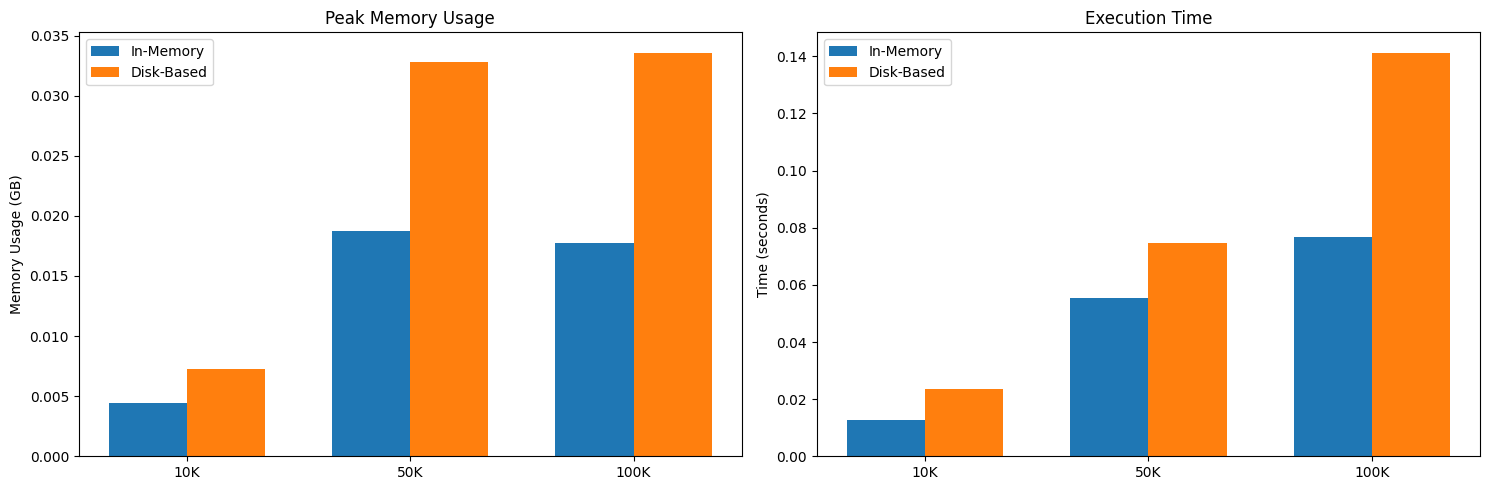

In [5]:
import time
import matplotlib.pyplot as plt
import tempfile

def benchmark_comparison(n_rows, n_cols, disk_mode=False):
    """Benchmark comparison performance."""
    try:
        # Create test datasets
        base_df = create_large_dataset(n_rows, n_cols, seed=42)
        compare_df, _ = create_delta_dataset(
            base_df, 
            delta_percentage=1.0, 
            seed=42,
            exclude_columns=["id", "timestamp"]
        )
        
        # Measure initial memory
        start_mem = get_memory_usage()
        start_time = time.time()
        
        if disk_mode:
            # Create temporary directory that will persist until we're done
            temp_dir = tempfile.mkdtemp()
            try:
                base_path = Path(temp_dir) / "base.parquet"
                compare_path = Path(temp_dir) / "compare.parquet"
                
                # Save to parquet files
                base_df.write_parquet(base_path)
                compare_df.write_parquet(compare_path)
                
                dc = DataCompare(
                    base_df=str(base_path),
                    compare_df=str(compare_path),
                    key_columns=["id"],
                    disk_mode=True,
                    optimize_dtypes=True,
                    temp_dir=temp_dir  # Use same temp dir for intermediate files
                )
                
                # Run comparison
                results = dc.compare()
                
                end_time = time.time()
                peak_mem = get_memory_usage()
                
                return {
                    "time": end_time - start_time,
                    "memory": peak_mem - start_mem,
                    "success": True
                }
            finally:
                # Clean up temp directory after we're completely done
                import shutil
                shutil.rmtree(temp_dir, ignore_errors=True)
        else:
            dc = DataCompare(
                base_df=base_df,
                compare_df=compare_df,
                key_columns=["id"]
            )
            
            # Run comparison
            results = dc.compare()
            
            end_time = time.time()
            peak_mem = get_memory_usage()
            
            return {
                "time": end_time - start_time,
                "memory": peak_mem - start_mem,
                "success": True
            }
            
    except Exception as e:
        print(f"Error in benchmark ({n_rows:,} rows): {str(e)}")
        return {
            "time": 0,
            "memory": 0,
            "success": False
        }

# Rest of the benchmark code remains the same...

# Test sizes
sizes = [
    (10_000, 10),
    (50_000, 10),
    (100_000, 10)
]

# Run benchmarks
results_memory = []
results_disk = []

for n_rows, n_cols in sizes:
    print(f"\nTesting with {n_rows:,} rows x {n_cols} columns")
    
    # Test in-memory mode
    print("Running in-memory comparison...")
    mem_result = benchmark_comparison(n_rows, n_cols, disk_mode=False)
    if mem_result["success"]:
        results_memory.append(mem_result)
    
    # Test disk mode
    print("Running disk-based comparison...")
    disk_result = benchmark_comparison(n_rows, n_cols, disk_mode=True)
    if disk_result["success"]:
        results_disk.append(disk_result)

# Plot results if we have any
if results_memory or results_disk:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    x = range(len(sizes[:len(results_memory)]))  # Only plot successful results
    width = 0.35

    # Memory usage comparison
    memory_in = [r["memory"] for r in results_memory]
    memory_disk = [r["memory"] for r in results_disk]

    if memory_in:
        ax1.bar([i - width/2 for i in x], memory_in, width, label='In-Memory')
    if memory_disk:
        ax1.bar([i + width/2 for i in x], memory_disk, width, label='Disk-Based')
    
    ax1.set_ylabel('Memory Usage (GB)')
    ax1.set_title('Peak Memory Usage')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{sizes[i][0]/1000:.0f}K" for i in x])
    ax1.legend()

    # Time comparison
    time_in = [r["time"] for r in results_memory]
    time_disk = [r["time"] for r in results_disk]

    if time_in:
        ax2.bar([i - width/2 for i in x], time_in, width, label='In-Memory')
    if time_disk:
        ax2.bar([i + width/2 for i in x], time_disk, width, label='Disk-Based')
    
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Execution Time')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{sizes[i][0]/1000:.0f}K" for i in x])
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No successful benchmarks to plot")

### Reports

In [6]:
# Cell 1: Generate reports for in-memory comparison
print("Generating in-memory comparison reports...")

# Create directories for results
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

# Load datasets
base_df = pl.read_parquet(base_path)
compare_df = pl.read_parquet(compare_path)

# Run in-memory comparison
print(f"\nInitial memory usage: {get_memory_usage():.2f} GB")
dc = DataCompare(
    base_df=base_df,
    compare_df=compare_df,
    key_columns=["id"]
)

results = dc.compare()
print(f"Peak memory usage: {get_memory_usage():.2f} GB")

# Generate reports
results.to_html(results_dir / "in_memory_comparison_report.html")
results.to_csv(results_dir / "in_memory_comparison_differences.csv")

# Print summary statistics
print("\nIn-Memory Comparison Summary:")
print(f"Total differences found: {results.total_differences}")
print(f"Number of columns with differences: {len(results.statistics)}")

# Clean up memory
del base_df, compare_df, results
_ = gc.collect()

Generating in-memory comparison reports...

Initial memory usage: 0.33 GB
Peak memory usage: 0.32 GB

In-Memory Comparison Summary:
Total differences found: 485
Number of columns with differences: 5


In [7]:
# Cell 2: Generate reports for disk-based comparison
print("Generating disk-based comparison reports...")

print(f"\nInitial memory usage: {get_memory_usage():.2f} GB")

# Create temporary directory for intermediate files
with tempfile.TemporaryDirectory() as temp_dir:
    # Use disk-based comparison with memory optimization
    dc = DataCompare(
        base_df=str(base_path),
        compare_df=str(compare_path),
        key_columns=["id"],
        disk_mode=True,
        optimize_dtypes=True,
        max_memory_usage=1024,  # 1GB memory limit
        temp_dir=temp_dir
    )

    print(f"\nStarting disk-based comparison...")
    results = dc.compare()

    print(f"Peak memory usage: {get_memory_usage():.2f} GB")

    # Generate reports
    results.to_html(results_dir / "disk_based_comparison_report.html")
    results.to_csv(results_dir / "disk_based_comparison_differences.csv")

    # Print summary statistics
    print("\nDisk-Based Comparison Summary:")
    print(f"Total differences found: {results.total_differences}")
    print(f"Number of columns with differences: {len(results.statistics)}")

    print("\nMemory Optimization:")
    if results.optimization_stats:
        original_mb = results.optimization_stats["original_size"] / (1024 * 1024)
        optimized_mb = results.optimization_stats["optimized_size"] / (1024 * 1024)
        reduction = results.optimization_stats["reduction_percent"]
        print(f"Original size: {original_mb:.2f} MB")
        print(f"Optimized size: {optimized_mb:.2f} MB")
        print(f"Memory reduction: {reduction:.1f}%")

Generating disk-based comparison reports...

Initial memory usage: 0.32 GB

Starting disk-based comparison...

Original schema:
__row_id: UInt32
id: Int64
timestamp: Datetime(time_unit='ms', time_zone=None)
int_col_0: Int64
float_col_1: Float64
cat_col_2: Utf8
int_col_3: Int64
float_col_4: Float64
Optimized id: Int64 -> UInt16
Optimized int_col_0: Int64 -> Int16
Optimized float_col_1: Float64 -> Float32
String column stats: 10 unique values out of 10000 (0.10%)
Converting to categorical (ratio 0.10% <= threshold 50.00%)
Optimized cat_col_2: Utf8 -> Categorical
Optimized int_col_3: Int64 -> Int16
Optimized float_col_4: Float64 -> Float32

Original schema:
__row_id: UInt32
id: Int64
timestamp: Datetime(time_unit='ms', time_zone=None)
int_col_0: Int64
float_col_1: Float64
cat_col_2: Utf8
int_col_3: Int64
float_col_4: Float64
Optimized id: Int64 -> UInt16
Optimized int_col_0: Int64 -> Int16
Optimized float_col_1: Float64 -> Float32
String column stats: 20 unique values out of 10000 (0.20%)

In [8]:
# Cell 3: Compare report differences
print("Comparing report differences...")

def load_and_compare_reports():
    """Load and compare the generated reports."""
    # Load HTML reports
    in_memory_html = Path(results_dir / "in_memory_comparison_report.html").read_text()
    disk_based_html = Path(results_dir / "disk_based_comparison_report.html").read_text()
    
    # Load CSV reports
    in_memory_df = pl.read_csv(results_dir / "in_memory_comparison_differences.csv")
    disk_based_df = pl.read_csv(results_dir / "disk_based_comparison_differences.csv")
    
    # Compare differences
    print("\nReport Statistics:")
    print(f"In-memory CSV rows: {len(in_memory_df)}")
    print(f"Disk-based CSV rows: {len(disk_based_df)}")
    
    # Compare differences in findings
    if len(in_memory_df) == len(disk_based_df):
        print("\nBoth methods found the same number of differences")
        
        # Sort both DataFrames the same way for comparison
        in_memory_df = in_memory_df.sort(["Variable", "Observation"])
        disk_based_df = disk_based_df.sort(["Variable", "Observation"])
        
        # Compare values
        differences = (
            in_memory_df
            .with_columns([
                (pl.col("Base_Value") != pl.lit(disk_based_df["Base_Value"])).alias("base_diff"),
                (pl.col("Compare_Value") != pl.lit(disk_based_df["Compare_Value"])).alias("compare_diff")
            ])
            .filter(pl.col("base_diff") | pl.col("compare_diff"))
        )
        
        if len(differences) == 0:
            print("Results are identical between methods")
        else:
            print(f"Found {len(differences)} rows with different values between methods")
            print("\nFirst few differences:")
            print(differences.head().to_pandas())
    else:
        print(f"\nDifferent number of findings between methods!")
        print(f"In-memory found: {len(in_memory_df)} differences")
        print(f"Disk-based found: {len(disk_based_df)} differences")

# Run comparison
load_and_compare_reports()

Comparing report differences...


ComputeError: Could not parse `cat_8` as dtype `f64` at column 'Base_Value' (column number 3).
The current offset in the file is 9110 bytes.

You might want to try:
- increasing `infer_schema_length` (e.g. `infer_schema_length=10000`),
- specifying correct dtype with the `dtypes` argument
- setting `ignore_errors` to `True`,
- adding `cat_8` to the `null_values` list.